# 01 – Data Preparation & Exploration
**Project:** AI Football Event Classifier (CNN) — Yannick Maas  
**Dataset:** [Soccer View and Event Score](https://www.kaggle.com/datasets/fahadahmedkhokhar/soccer-view-and-event-score)

This notebook:
1. Reads the dataset folder structure
2. Samples a small, manageable subset of images
3. Visualises class distributions (event & view labels)
4. Applies preprocessing / augmentation and saves a ready-to-use CSV manifest

> ⚠️ **Important**: Because the full dataset has ~38 000 images, we limit ourselves to **`MAX_PER_CLASS`** images per class to avoid memory/runtime issues.

In [4]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import random
import csv
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

random.seed(42)
np.random.seed(42)

print('Libraries loaded ✓')

Libraries loaded ✓


In [5]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Adjust DATASET_ROOT to wherever you extracted the Kaggle dataset.
# Expected layout (two levels):
#   <DATASET_ROOT>/<event_label>/<view_label>/<image>.jpg
# e.g.  data/soccer/goal/close_up/img001.jpg

DATASET_ROOT = Path('C:\\Users\\Yannick\\data\\soccer')          # ← change this
OUTPUT_DIR   = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

IMG_SIZE     = (224, 224)   # target size for the model
MAX_PER_CLASS = 150         # max images per (event, view) combination — keep small!

print(f'Dataset root : {DATASET_ROOT.resolve()}')
print(f'Images will be resized to {IMG_SIZE}')
print(f'Max per class: {MAX_PER_CLASS}')

Dataset root : C:\Users\Yannick\data\soccer
Images will be resized to (224, 224)
Max per class: 150


In [6]:
# ── 1. Explore folder structure ───────────────────────────────────────────────
records = []   # list of dicts: {path, event_label, view_label}

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f'{DATASET_ROOT} does not exist.\n'
        'Please download the Kaggle dataset and set DATASET_ROOT correctly.')

for event_dir in sorted(DATASET_ROOT.iterdir()):
    if not event_dir.is_dir():
        continue
    event_label = event_dir.name
    for view_dir in sorted(event_dir.iterdir()):
        if not view_dir.is_dir():
            continue
        view_label = view_dir.name
        images = list(view_dir.glob('*.jpg')) + list(view_dir.glob('*.png'))
        for img_path in images:
            records.append({
                'path'        : str(img_path),
                'event_label' : event_label,
                'view_label'  : view_label,
            })

df_all = pd.DataFrame(records)
print(f'Total images found : {len(df_all):,}')
print(f'Event classes      : {df_all["event_label"].nunique()} → {sorted(df_all["event_label"].unique())}')
print(f'View classes       : {df_all["view_label"].nunique()} → {sorted(df_all["view_label"].unique())}')
df_all.head()

Total images found : 138,445
Event classes      : 2 → ['EventClasses', 'ViewClasses']
View classes       : 14 → ['MediumView', 'OuterView', 'ShotView', 'corner', 'freekick', 'gattempts', 'goal', 'longView', 'offside', 'playercelebration', 'plentystock', 'redc', 'spectator', 'yellowcard']


,path,event_label,view_label
0,C:\Users\Yannick\data\soccer\EventClasses\corn...,EventClasses,corner
1,C:\Users\Yannick\data\soccer\EventClasses\corn...,EventClasses,corner
2,C:\Users\Yannick\data\soccer\EventClasses\corn...,EventClasses,corner
3,C:\Users\Yannick\data\soccer\EventClasses\corn...,EventClasses,corner
4,C:\Users\Yannick\data\soccer\EventClasses\corn...,EventClasses,corner


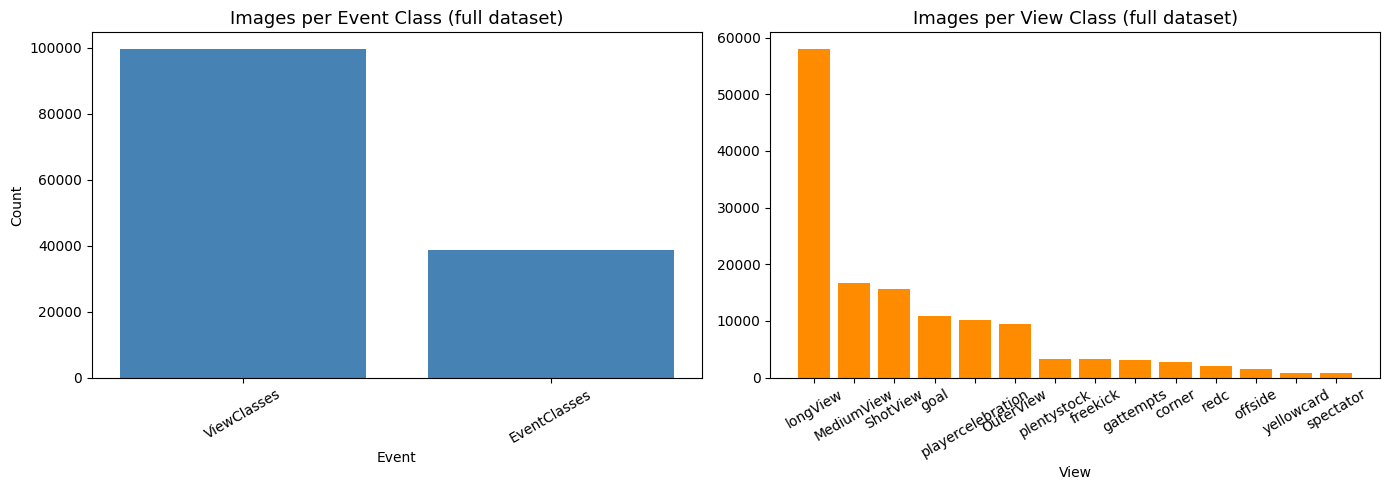

Saved → outputs/class_distribution.png


In [7]:
# ── 2. Class distribution plots ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

event_counts = df_all['event_label'].value_counts()
axes[0].bar(event_counts.index, event_counts.values, color='steelblue')
axes[0].set_title('Images per Event Class (full dataset)', fontsize=13)
axes[0].set_xlabel('Event')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

view_counts = df_all['view_label'].value_counts()
axes[1].bar(view_counts.index, view_counts.values, color='darkorange')
axes[1].set_title('Images per View Class (full dataset)', fontsize=13)
axes[1].set_xlabel('View')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=120)
plt.show()
print('Saved → outputs/class_distribution.png')

In [8]:
# ── 3. Sample a balanced subset ───────────────────────────────────────────────
sampled_groups = []
for (event, view), group in df_all.groupby(['event_label', 'view_label']):
    n = min(len(group), MAX_PER_CLASS)
    sampled_groups.append(group.sample(n, random_state=42))

df = pd.concat(sampled_groups, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f'Subset size : {len(df):,} images')
print(df[['event_label', 'view_label']].value_counts().to_string())

Subset size : 2,100 images
event_label   view_label       
EventClasses  corner               150
              freekick             150
              gattempts            150
              goal                 150
              offside              150
              playercelebration    150
              plentystock          150
              redc                 150
              spectator            150
              yellowcard           150
ViewClasses   MediumView           150
              OuterView            150
              ShotView             150
              longView             150


In [9]:
# ── 4. Verify images & collect basic stats ────────────────────────────────────
broken = []
widths, heights = [], []

for path in df['path']:
    try:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)
    except Exception:
        broken.append(path)

print(f'Broken / unreadable images: {len(broken)}')
print(f'Width  — min:{min(widths)}, max:{max(widths)}, mean:{int(np.mean(widths))}')
print(f'Height — min:{min(heights)}, max:{max(heights)}, mean:{int(np.mean(heights))}')

if broken:
    df = df[~df['path'].isin(broken)].reset_index(drop=True)
    print(f'Removed broken images → {len(df):,} remain')

Broken / unreadable images: 0
Width  — min:540, max:1280, mean:878
Height — min:352, max:720, mean:495


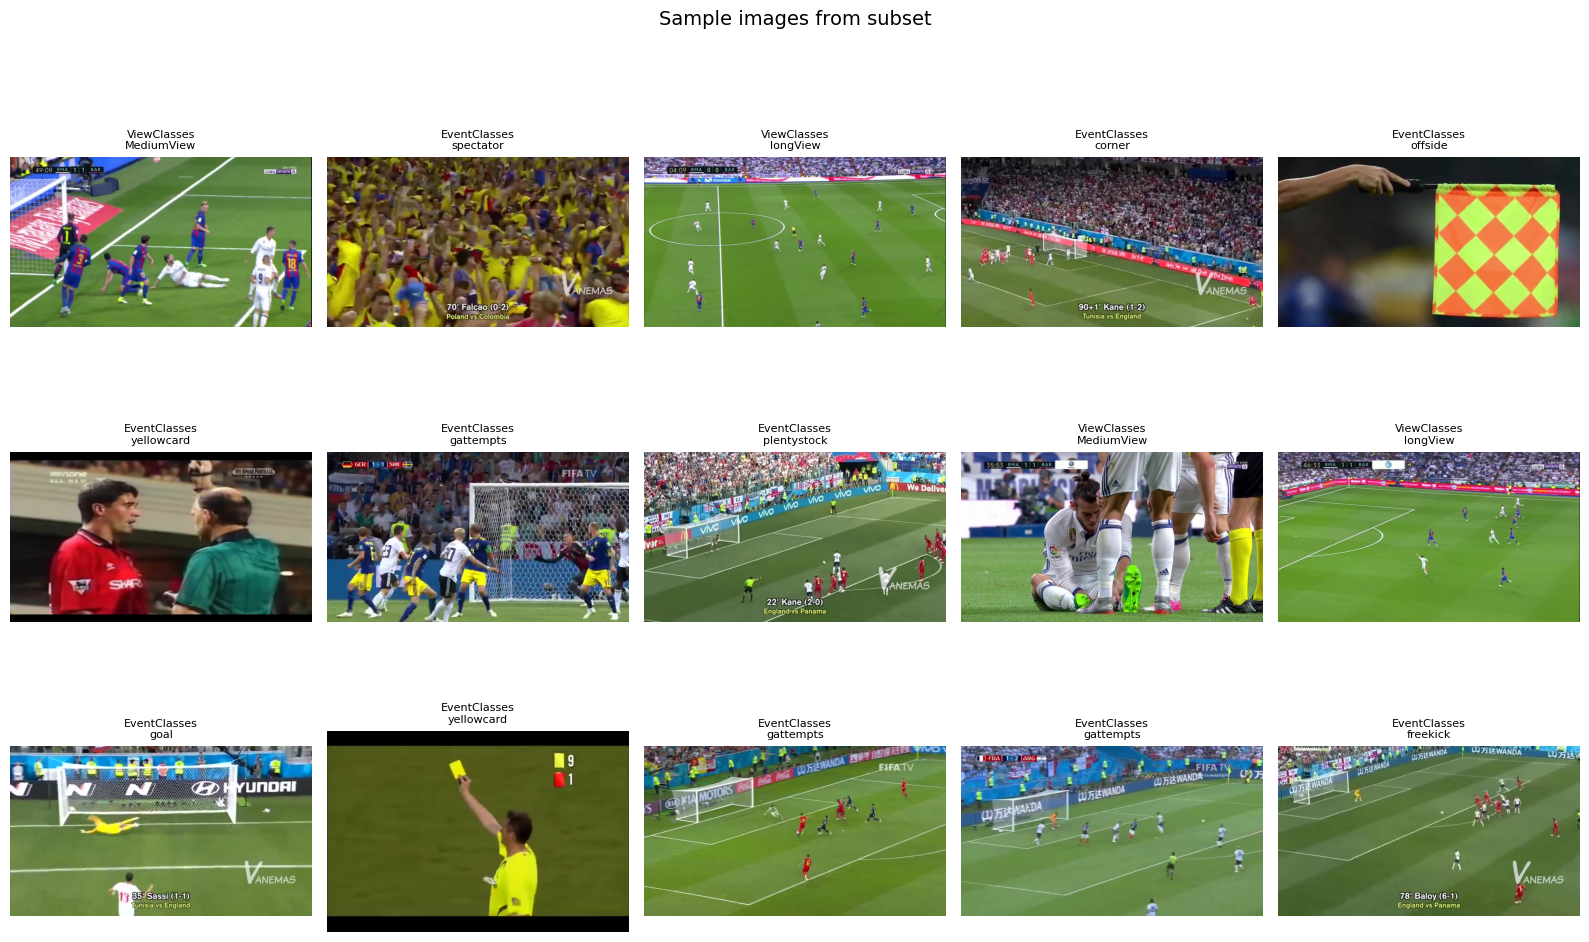

Saved → outputs/sample_images.png


In [10]:
# ── 5. Visualise sample images ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
sample = df.sample(15, random_state=7)

for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = mpimg.imread(row['path'])
    ax.imshow(img)
    ax.set_title(f"{row['event_label']}\n{row['view_label']}", fontsize=8)
    ax.axis('off')

plt.suptitle('Sample images from subset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → outputs/sample_images.png')

In [11]:
# ── 6. Add integer label columns & train/val/test split ───────────────────────
from sklearn.model_selection import train_test_split

event_classes = sorted(df['event_label'].unique())
view_classes  = sorted(df['view_label'].unique())

event2idx = {c: i for i, c in enumerate(event_classes)}
view2idx  = {c: i for i, c in enumerate(view_classes)}

df['event_idx'] = df['event_label'].map(event2idx)
df['view_idx']  = df['view_label'].map(view2idx)

# Stratify on event class for a representative split
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['event_idx'], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['event_idx'], random_state=42)

df['split'] = 'train'
df.loc[val_df.index, 'split']  = 'val'
df.loc[test_df.index, 'split'] = 'test'

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'{split_name:5s}: {len(split_df):5,} images')

print(f'\nEvent label map : {event2idx}')
print(f'View  label map : {view2idx}')

train: 1,470 images
val  :   315 images
test :   315 images

Event label map : {'EventClasses': 0, 'ViewClasses': 1}
View  label map : {'MediumView': 0, 'OuterView': 1, 'ShotView': 2, 'corner': 3, 'freekick': 4, 'gattempts': 5, 'goal': 6, 'longView': 7, 'offside': 8, 'playercelebration': 9, 'plentystock': 10, 'redc': 11, 'spectator': 12, 'yellowcard': 13}


In [12]:
# ── 7. Save manifest CSV ──────────────────────────────────────────────────────
manifest_path = OUTPUT_DIR / 'manifest.csv'
df.to_csv(manifest_path, index=False)
print(f'Manifest saved → {manifest_path}  ({len(df):,} rows)')
df.head()

Manifest saved → outputs\manifest.csv  (2,100 rows)


,path,event_label,view_label,event_idx,view_idx,split
0,C:\Users\Yannick\data\soccer\EventClasses\plen...,EventClasses,plentystock,0,10,train
1,C:\Users\Yannick\data\soccer\EventClasses\redc...,EventClasses,redc,0,11,test
2,C:\Users\Yannick\data\soccer\EventClasses\corn...,EventClasses,corner,0,3,train
3,C:\Users\Yannick\data\soccer\EventClasses\spec...,EventClasses,spectator,0,12,train
4,C:\Users\Yannick\data\soccer\EventClasses\offs...,EventClasses,offside,0,8,val


## Summary

| Item | Value |
|------|-------|
| Total images in subset | see above |
| Event classes | `event2idx` dict above |
| View classes | `view2idx` dict above |
| Train / Val / Test | 70 / 15 / 15 % |
| Manifest file | `outputs/manifest.csv` |

➡️ Continue with **`02_baseline_model.ipynb`** to train a CNN from scratch.